# **Predicting Used Car Prices Using Regression Analysis**

## ***Importing Libraries***

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

## ***Data Loading***

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Sample Data Sets/used_cars.csv")
data.head()


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [ ]:
data.shape

(4009, 12)

## ***Basic Data Exploration***


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


## ***Changing Data Types and Handling Null Values***

In [ ]:
## brand
data['brand'] = data['brand'].astype('category')

## model
data['model'] = data['model'].astype('category')

## model_year
data['model_year'] = data['model_year'].astype('int64')

## mileage
data = data.rename(columns={'milage': 'total_miles'})
data['total_miles'] = (data['total_miles'].str.replace(',', '').str.replace(' mi.', '')).astype('int64')

## fuel_type
data['fuel_type'] = data['fuel_type'].astype('category')
'''
Since 'fuel_type' is of Categorical Dtype, so filling Nan with Mode is best suited.
'''
fuel_type_mode = data['fuel_type'].mode()[0]
data['fuel_type'] = data['fuel_type'].fillna(fuel_type_mode)

## engine
  # Extract the numbers before 'HP'
data['horsepower'] = data['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)
  # Handling Missing Values in 'horsepower'
'''
Since horsepower is a numeric value that can have extreme outliers (like a 700HP supercar vs. a 150HP sedan), we should use the Median to fill these nulls.
The median is safer than the mean because it isn't pulled away by those extreme high-performance cars.
'''
hp_median = data['horsepower'].median()
data['horsepower'] = data['horsepower'].fillna(hp_median)

  # Extract the numbers before 'L'
data['engine_displacement'] = data['engine'].str.extract(r'(\d+\.?\d*)L').astype(float)
    # Handling Missing Values in 'engine_displacement'
'''
Just like with horsepower, engine size can have outliers—ranging from tiny 1.2L economy engines to massive 6.2L V8s.
Therefore, using the Median is the most robust way to fill these gaps without letting extreme values skew your data.
'''
displacement_median = data['engine_displacement'].median()
data['engine_displacement'] = data['engine_displacement'].fillna(displacement_median)

  # Finally, making the original engine column a category
data['engine'] = data['engine'].astype('category')

## transmission

  # Extract the number of speeds (e.g., '6' from '6-Speed')
data['transmission_speeds'] = data['transmission'].str.extract(r'(\d+)-Speed').astype(float)
'''
Since the number of speeds is a discrete count (you can't have 6.5 speeds), you should use the Mode (the most common speed) to fill these gaps.
'''
transmission_mode = data['transmission_speeds'].mode()[0]
data['transmission_speeds'] = data['transmission_speeds'].fillna(transmission_mode)

  # Create a simple binary column for Automatic vs Manual
data['is_automatic'] = data['transmission'].str.contains('Automatic|A/T|CVT', case=False).astype(int)

  # Finally, making the original transmission column a category
data['transmission'] = data['transmission'].astype('category')

# ext_col
data['ext_col'] = data['ext_col'].astype('category')

# int_col
data['int_col'] = data['int_col'].astype('category')

# accident
data['accident'] = data['accident'].apply(lambda x: 1 if x == 'At least 1 accident or damage reported' else 0)

# clean_title
data['clean_title'] = data['clean_title'].apply(lambda x: 1 if x == 'Yes' else 0)

# price
data['price'] = data['price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)


## ***Handaling Null/ missing values***

In [ ]:
# Checking for the Missing Values
data.isnull().sum()

,0
brand,0
model,0
model_year,0
total_miles,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


In [ ]:
data.columns

Index(['brand', 'model', 'model_year', 'total_miles', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price', 'horsepower', 'engine_displacement', 'transmission_speeds',
       'is_automatic'],
      dtype='object')

In [ ]:
clean_data = data[['brand', 'model', 'model_year', 'total_miles',
                   'fuel_type', 'horsepower', 'engine_displacement',
                   'transmission_speeds', 'is_automatic',
                   'accident', 'clean_title', 'price']].copy()

In [ ]:
clean_data.head()


,brand,model,model_year,total_miles,fuel_type,horsepower,engine_displacement,transmission_speeds,is_automatic,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0,3.7,6.0,1,1,1,10300.0
1,Hyundai,Palisade SEL,2021,34742,Gasoline,310.0,3.8,8.0,1,1,1,38005.0
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,310.0,3.5,6.0,1,0,0,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0,3.5,7.0,1,0,1,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,310.0,2.0,8.0,1,0,0,34999.0


### ***Exploratory Data Analysis (EDA)***

## ***Understand the Target Variable (Price)***

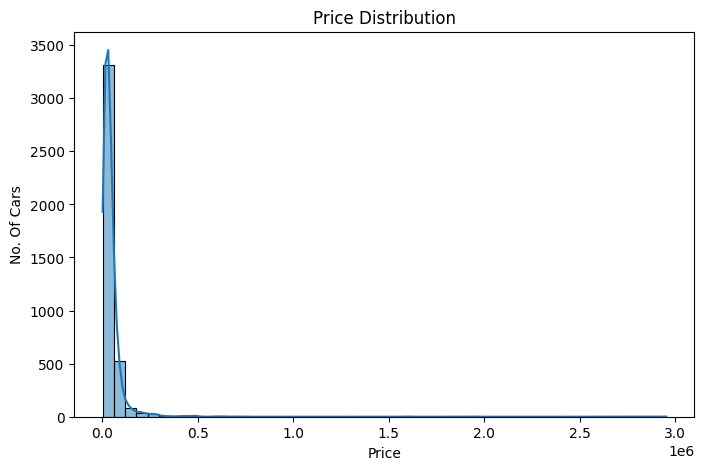

In [ ]:
# Plotting Price Distribution
plt.figure(figsize=(8,5))

sns.histplot(clean_data['price'], bins=50, kde=True)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("No. Of Cars")
plt.show()

In [ ]:
clean_data['price'].describe()

,price
count,4.009000e+03
mean,4.455319e+04
std,7.871064e+04
min,2.000000e+03
25%,1.720000e+04
50%,3.100000e+04
75%,4.999000e+04
max,2.954083e+06


Skewness before log transformation: 19.50624929114917


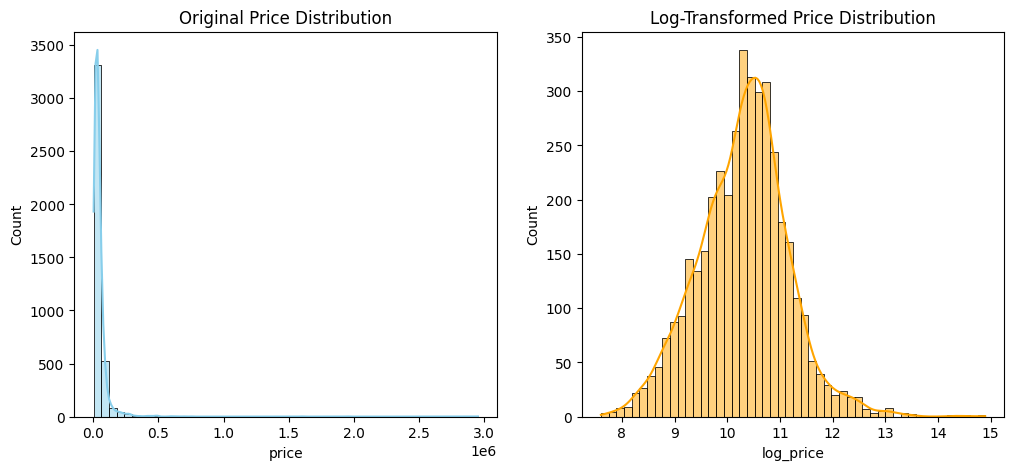

In [ ]:
# Check skewness
skew_value = skew(clean_data['price'])
print("Skewness before log transformation:", skew_value)

# Apply log transformation if skewed
clean_data['log_price'] = np.log(clean_data['price'])

# Plot before and after
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(clean_data['price'], bins=50, kde=True, color='skyblue')
plt.title("Original Price Distribution")

plt.subplot(1,2,2)
sns.histplot(clean_data['log_price'], bins=50, kde=True, color='orange')
plt.title("Log-Transformed Price Distribution")

plt.show()


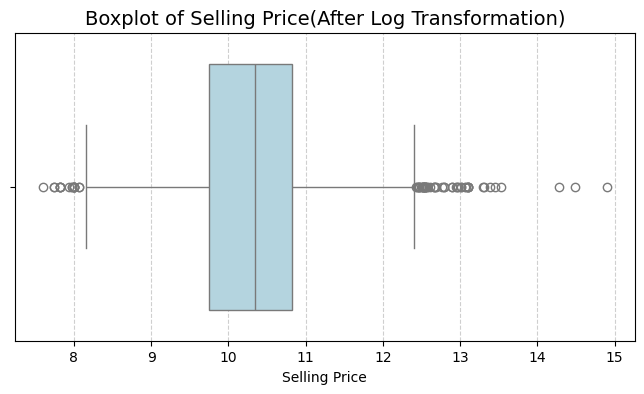

In [ ]:
plt.figure(figsize=(8,4))

# Seaborn boxplot (uses Matplotlib under the hood)
sns.boxplot(x=clean_data['log_price'], color='lightblue')

# Matplotlib customization
plt.title("Boxplot of Selling Price(After Log Transformation)", fontsize=14)
plt.xlabel("Selling Price")
plt.grid(True, axis='x', linestyle='--', alpha=0.6)

plt.show()

## ***Relationship Between Features and Price***


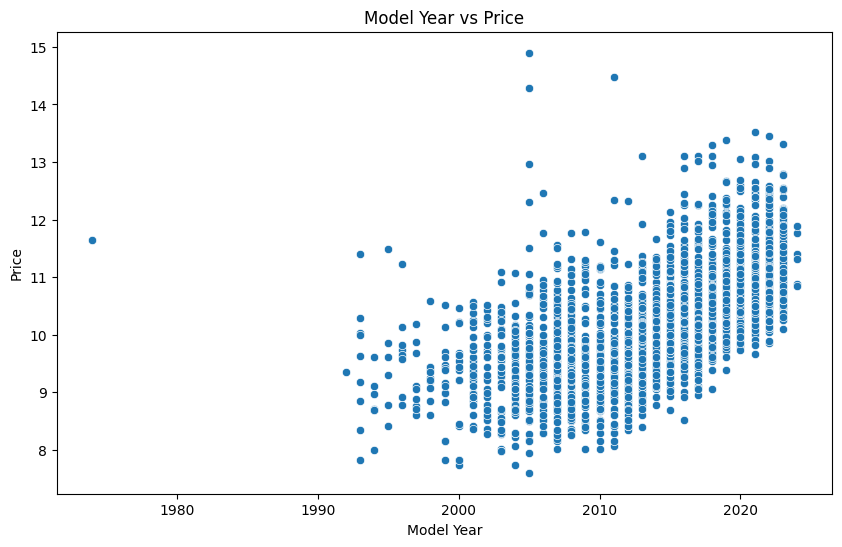


Conclusion : Newer cars cost more.


In [ ]:
# Model Year vs Price

plt.figure(figsize=(10, 6))
sns.scatterplot(x='model_year', y='log_price', data=clean_data)
plt.title('Model Year vs Price')
plt.xlabel('Model Year')
plt.ylabel('Price')
plt.show()

print("\nConclusion : Newer cars cost more.")

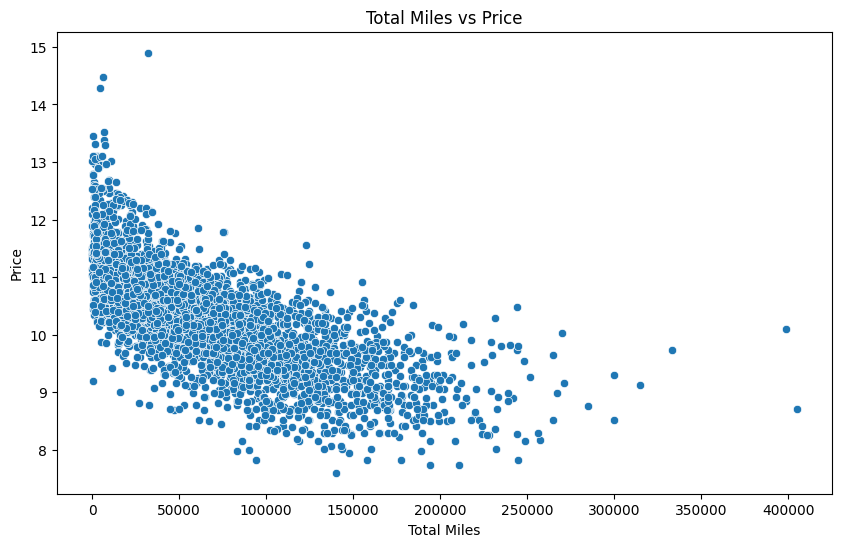


Conclusion : More Miles driven cars cost less.


In [ ]:
# Total Miles vs Price

plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_miles', y='log_price', data=clean_data)
plt.title('Total Miles vs Price')
plt.xlabel('Total Miles')
plt.ylabel('Price')
plt.show()

print("\nConclusion : More Miles driven cars cost less.")

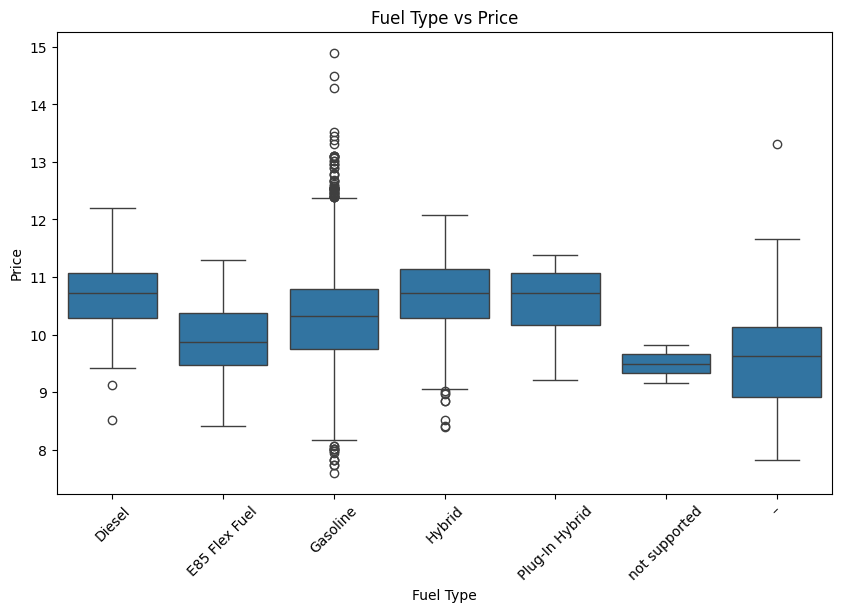


Conclusion : Gasoline Cars Have the Most Price Variation.


In [ ]:
# Fuel Type vs Price

plt.figure(figsize=(10, 6))
sns.boxplot(x='fuel_type', y='log_price', data=clean_data)
plt.title('Fuel Type vs Price')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

print("\nConclusion : Gasoline Cars Have the Most Price Variation.")

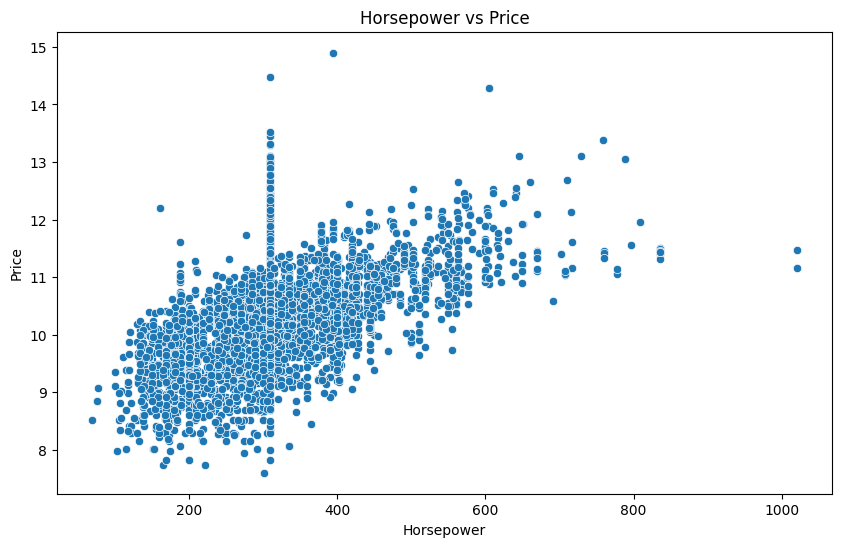


Conclusion : More Horsepower cars tends to cost more.


In [ ]:
# Horsepower vs Price

plt.figure(figsize=(10, 6))
sns.scatterplot(x='horsepower', y='log_price', data=clean_data)
plt.title('Horsepower vs Price')
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.show()

print("\nConclusion : More Horsepower cars tends to cost more.")

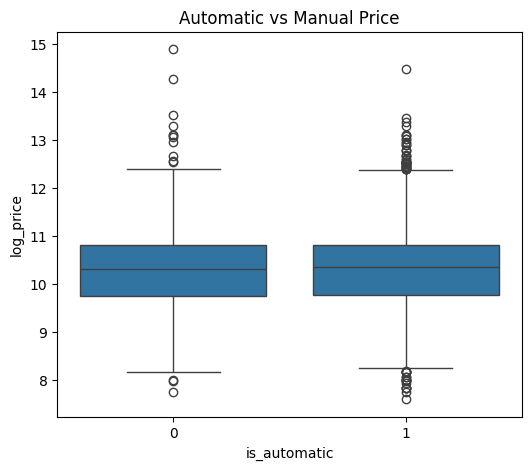


Conclusion: Automatic Cars tends to be priced higher


In [ ]:
# Automatic vs Manual Cars

plt.figure(figsize=(6,5))
sns.boxplot(x='is_automatic', y='log_price', data=clean_data)
plt.title("Automatic vs Manual Price")
plt.show()

print("\nConclusion: Automatic Cars tends to be priced higher")

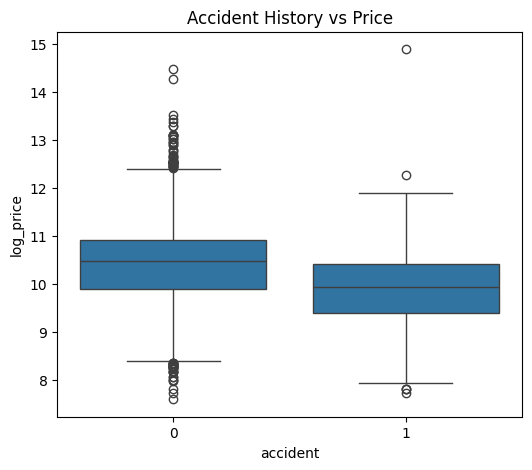


Conclusion : Cars with accidents cost less.


In [ ]:
# Accident History vs Price

plt.figure(figsize=(6,5))
sns.boxplot(x='accident', y='log_price', data=clean_data)
plt.title("Accident History vs Price")
plt.show()

print("\nConclusion : Cars with accidents cost less.")

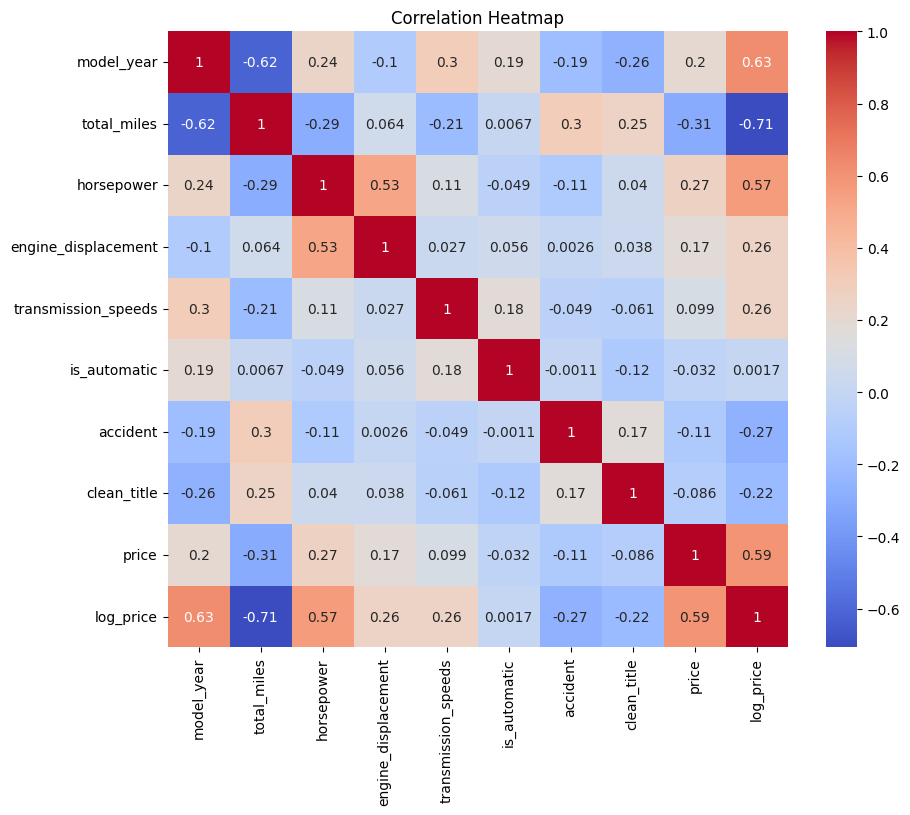

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(10,8))
corr = clean_data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Calculate correlations with price
corr_with_price = clean_data.corr(numeric_only=True)['log_price'].sort_values(ascending=False).to_string()

print(corr_with_price)

log_price              1.000000
model_year             0.625215
price                  0.594015
horsepower             0.565195
engine_displacement    0.257060
transmission_speeds    0.255729
is_automatic           0.001704
clean_title           -0.218881
accident              -0.268200
total_miles           -0.707796


## ***Prepare Data for Machine Learning***

In [ ]:
# ML models only understand numbers, not text like "Toyota" or "Gasoline"
# So we use LabelEncoder to convert categories to numbers

le = LabelEncoder()
for col in ['brand', 'model', 'fuel_type']:
    clean_data[col] = le.fit_transform(clean_data[col].astype(str))
    print(f"   ✅ '{col}' encoded")

# Features (X) = everything except price columns
# Target  (y) = log_price (we predict log price, then convert back)
X = clean_data.drop(columns=['price', 'log_price'])
y = clean_data['log_price']

print(f"\n✅ Features (X): {X.shape[1]} columns")
print(f"✅ Target   (y): log_price")

   ✅ 'brand' encoded
   ✅ 'model' encoded
   ✅ 'fuel_type' encoded

✅ Features (X): 11 columns
✅ Target   (y): log_price


## ***Split into Train & Test***

In [ ]:
# 80% data for training, 20% for testing
# random_state=42 means results are same every time you run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f" Training set : {X_train.shape[0]} rows")
print(f" Testing set  : {X_test.shape[0]} rows")

 Training set : 3207 rows
 Testing set  : 802 rows


## ***Model 1 — Linear Regression***

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)           # Train the model
y_pred_lr = lr.predict(X_test)     # Predict on test data

# Evaluate
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"   MAE  (Mean Absolute Error) : {mae_lr:.4f}")
print(f"   RMSE (Root Mean Sq. Error) : {rmse_lr:.4f}")
print(f"   R²   (How well it fits)    : {r2_lr:.4f}")
print(f"   → Model explains {r2_lr*100:.1f}% of price variation")

   MAE  (Mean Absolute Error) : 0.3264
   RMSE (Root Mean Sq. Error) : 0.4883
   R²   (How well it fits)    : 0.6939
   → Model explains 69.4% of price variation


## ***Model 2 — Random Forest***

In [ ]:
# Smarter model — uses many decision trees and averages their results

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"   MAE  (Mean Absolute Error) : {mae_rf:.4f}")
print(f"   RMSE (Root Mean Sq. Error) : {rmse_rf:.4f}")
print(f"   R²   (How well it fits)    : {r2_rf:.4f}")
print(f"   → Model explains {r2_rf*100:.1f}% of price variation")

   MAE  (Mean Absolute Error) : 0.2433
   RMSE (Root Mean Sq. Error) : 0.3855
   R²   (How well it fits)    : 0.8092
   → Model explains 80.9% of price variation


## ***Comparing Both Models***

            Model    MAE   RMSE  R² Score
Linear Regression 0.3264 0.4883    0.6939
    Random Forest 0.2433 0.3855    0.8092


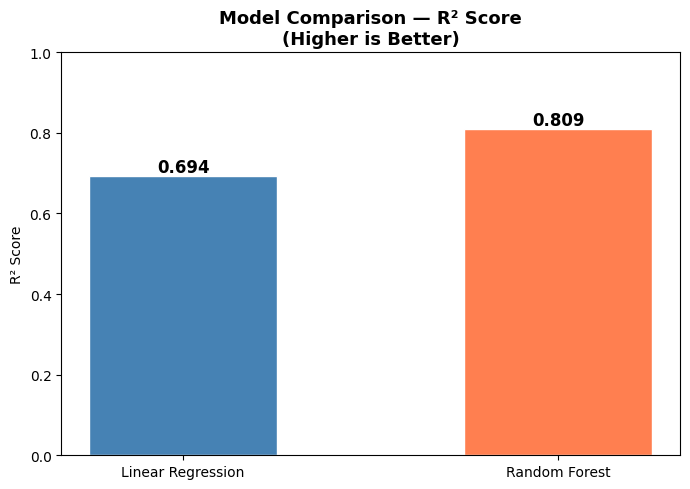

In [ ]:
comparison = pd.DataFrame({
    'Model'  : ['Linear Regression', 'Random Forest'],
    'MAE'    : [round(mae_lr,  4), round(mae_rf,  4)],
    'RMSE'   : [round(rmse_lr, 4), round(rmse_rf, 4)],
    'R² Score': [round(r2_lr,  4), round(r2_rf,   4)],
})
print(comparison.to_string(index=False))

# Bar chart — R² comparison
plt.figure(figsize=(7, 5))
plt.bar(['Linear Regression', 'Random Forest'],
        [r2_lr, r2_rf], color=['steelblue', 'coral'], edgecolor='white', width=0.5)
plt.title("Model Comparison — R² Score\n(Higher is Better)", fontsize=13, fontweight='bold')
plt.ylabel("R² Score")
plt.ylim(0, 1)
for i, v in enumerate([r2_lr, r2_rf]):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout() #Automatically adjust spacing between plots and labels
plt.show()

## ***Actual vs Predicted (Random Forest)***

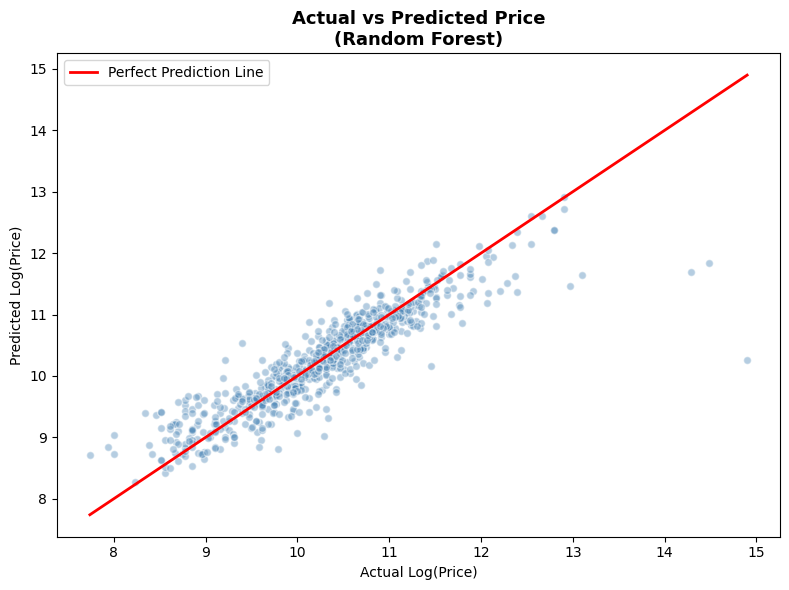

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue', edgecolors='white', s=30)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect Prediction Line')
plt.title("Actual vs Predicted Price\n(Random Forest)", fontsize=13, fontweight='bold')
plt.xlabel("Actual Log(Price)")
plt.ylabel("Predicted Log(Price)")
plt.legend()
plt.tight_layout()
plt.show()

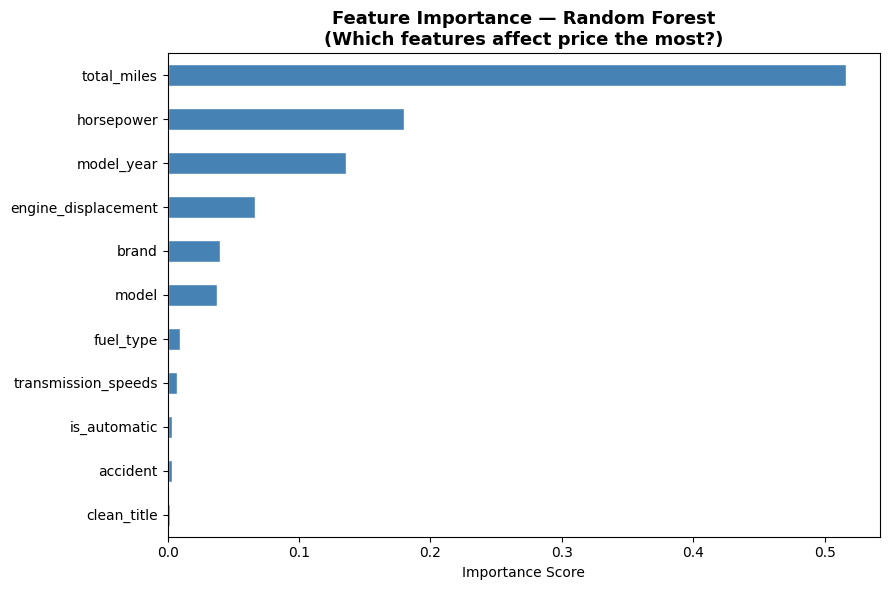


── Top 5 Features That Affect Car Price ──
total_miles            0.516210
horsepower             0.179904
model_year             0.135582
engine_displacement    0.066122
brand                  0.039583


In [ ]:
# ── STEP 14: Feature Importance (Random Forest) ───────────────
# Which features matter the most when predicting price?
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title("Feature Importance — Random Forest\n(Which features affect price the most?)",
          fontsize=13, fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\n── Top 5 Features That Affect Car Price ──")
print(importances.sort_values(ascending=False).head(5).to_string())

In [ ]:
# ── FINAL SUMMARY ─────────────────────────────────────────────
print("\n" + "="*55)
print("PROJECT SUMMARY — Used Car Price Prediction")
print("="*55)
print(f"Total Cars Analysed     : {len(clean_data)}")
print(f"Features Used           : {X.shape[1]}")
print(f"Train / Test Split      : 80% / 20%")
print(f"\nLinear Regression R²    : {r2_lr*100:.1f}%")
print(f"Random Forest R²        : {r2_rf*100:.1f}%  ← Better Model")
print(f"\nBest Model              : Random Forest")
print(f"Key Finding             : Model year and total miles are")
print(f"                          the strongest predictors of price")


PROJECT SUMMARY — Used Car Price Prediction
Total Cars Analysed     : 4009
Features Used           : 11
Train / Test Split      : 80% / 20%

Linear Regression R²    : 69.4%
Random Forest R²        : 80.9%  ← Better Model

Best Model              : Random Forest
Key Finding             : Model year and total miles are
                          the strongest predictors of price
